In [51]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

np.set_printoptions(precision=6, suppress=True)

In [52]:
def terminal_cost(xT, y):
    """
    J = 1/2 ||x(T) - y||^2
    """
    r = xT - y
    return 0.5 * np.dot(r, r)


def numerical_jacobian(f, t, x, eps=1e-6):
    """
    Centered finite-difference Jacobian of f with respect to x.
    """
    x = np.asarray(x, dtype=float)
    n = len(x)
    J = np.zeros((n, n))

    for j in range(n):
        dx = np.zeros(n)
        dx[j] = eps

        fp = f(t, x + dx)
        fm = f(t, x - dx)

        J[:, j] = (fp - fm) / (2.0 * eps)

    return J

In [53]:
def terminal_cost(xT, y):
    """
    J = 1/2 ||x(T) - y||^2
    """
    r = xT - y
    return 0.5 * np.dot(r, r)


def numerical_jacobian(f, t, x, eps=1e-6):
    """
    Centered finite-difference Jacobian of f with respect to x.
    """
    x = np.asarray(x, dtype=float)
    n = len(x)
    J = np.zeros((n, n))

    for j in range(n):
        dx = np.zeros(n)
        dx[j] = eps

        fp = f(t, x + dx)
        fm = f(t, x - dx)

        J[:, j] = (fp - fm) / (2.0 * eps)

    return J

In [54]:
def solve_forward(f, x0, T, rtol=1e-9, atol=1e-11):
    """
    Solve x_dot = f(t,x) forward from 0 to T.
    Dense output is needed so the backward adjoint can evaluate x(t).
    """
    sol = solve_ivp(
        f,
        (0.0, T),
        np.asarray(x0, dtype=float),
        method="DOP853",
        dense_output=True,
        rtol=rtol,
        atol=atol
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    return sol


def adjoint_gradient(f, jac, x0, y, T, rtol=1e-8, atol=1e-10):
    """
    Compute J and grad_{x0} J using the continuous adjoint.

    State:
        x_dot = f(t,x)

    Terminal cost:
        J = 1/2 ||x(T)-y||^2

    Adjoint:
        lambda_dot = -Df(x)^T lambda
        lambda(T) = x(T)-y

    Returns:
        J, gradient, forward solution, adjoint solution
    """
    # Forward state
    state_sol = solve_forward(f, x0, T)

    xT = state_sol.y[:, -1]
    J = terminal_cost(xT, y)

    # Terminal condition for the adjoint
    lambda_T = xT - y

    def adjoint_rhs(t, lam):
        x = state_sol.sol(t)
        A = jac(t, x)
        return -A.T @ lam

    # Integrate backward from T to 0
    adj_sol = solve_ivp(
        adjoint_rhs,
        (T, 0.0),
        lambda_T,
        method="DOP853",
        rtol=rtol,
        atol=atol
    )

    if not adj_sol.success:
        raise RuntimeError(adj_sol.message)

    grad = adj_sol.y[:, -1]

    return J, grad, state_sol, adj_sol

In [55]:
def cost_from_initial_condition(f, x0, y, T):
    sol = solve_forward(f, x0, T)
    return terminal_cost(sol.y[:, -1], y)


def directional_derivative_check(
    name, f, jac, x0, y, T, seed=1234, eps=1e-5
):
    rng = np.random.default_rng(seed)

    h = rng.normal(size=len(x0))
    h /= np.linalg.norm(h)

    # Adjoint gradient
    J, grad, _, _ = adjoint_gradient(f, jac, x0, y, T)

    adjoint_dd = np.dot(grad, h)

    # Centered finite difference
    J_plus = cost_from_initial_condition(
        f, x0 + eps * h, y, T
    )

    J_minus = cost_from_initial_condition(
        f, x0 - eps * h, y, T
    )

    fd_dd = (J_plus - J_minus) / (2.0 * eps)

    denom = max(1.0, abs(adjoint_dd), abs(fd_dd))
    rel_error = abs(adjoint_dd - fd_dd) / denom

    print(f"{name}")
    print("-" * len(name))
    print(f"J                  = {J:.8e}")
    print(f"Adjoint derivative = {adjoint_dd:.8e}")
    print(f"Finite difference  = {fd_dd:.8e}")
    print(f"Relative error     = {rel_error:.8e}")
    print()

    return {
        "name": name,
        "J": J,
        "adjoint": adjoint_dd,
        "finite_difference": fd_dd,
        "relative_error": rel_error,
        "gradient": grad
    }

In [56]:
sigma = 10.0
rho = 28.0
beta_l63 = 8.0 / 3.0


def lorenz63(t, x):
    X, Y, Z = x

    return np.array([
        sigma * (Y - X),
        X * (rho - Z) - Y,
        X * Y - beta_l63 * Z
    ])


def jac_lorenz63(t, x):
    X, Y, Z = x

    return np.array([
        [-sigma,       sigma,       0.0],
        [rho - Z,      -1.0,        -X],
        [Y,             X,    -beta_l63]
    ])

In [57]:
K = 40
F = 8.0
d = 1.0


def lorenz96(t, u):
    du = np.zeros(K)

    for k in range(K):
        km1 = (k - 1) % K
        km2 = (k - 2) % K
        kp1 = (k + 1) % K

        du[k] = (
            u[km1] * (u[kp1] - u[km2])
            - d * u[k]
            + F
        )

    return du


def jac_lorenz96(t, u):
    A = np.zeros((K, K))

    for k in range(K):
        km1 = (k - 1) % K
        km2 = (k - 2) % K
        kp1 = (k + 1) % K

        A[k, km1] += u[kp1] - u[km2]
        A[k, kp1] += u[km1]
        A[k, km2] += -u[km1]
        A[k, k] += -d

    return A

In [58]:
K2 = 40
J2 = 5
F2 = 8.0
d2 = 1.0

gamma = 0.05 * np.ones(J2)

# IMPORTANT:
# Replace this with the exact ds array from your Homework 1 notebook
# if you used different values.
ds = np.ones(J2)


def lorenz96_two_layer(t, state):
    u = state[:K2]
    v = state[K2:].reshape(K2, J2)

    du = np.zeros(K2)
    dv = np.zeros((K2, J2))

    for k in range(K2):
        km1 = (k - 1) % K2
        km2 = (k - 2) % K2
        kp1 = (k + 1) % K2

        coupling = np.dot(gamma, v[k])

        du[k] = (
            u[km1] * (u[kp1] - u[km2])
            + coupling * u[k]
            - d2 * u[k]
            + F2
        )

        for j in range(J2):
            dv[k, j] = (
                -ds[j] * v[k, j]
                - gamma[j] * u[k]**2
            )

    return np.concatenate([du, dv.ravel()])


def jac_lorenz96_two_layer(t, state):
    u = state[:K2]
    v = state[K2:].reshape(K2, J2)

    n = K2 + K2 * J2
    A = np.zeros((n, n))

    for k in range(K2):
        km1 = (k - 1) % K2
        km2 = (k - 2) % K2
        kp1 = (k + 1) % K2

        coupling = np.dot(gamma, v[k])

        # du_k / du
        A[k, km1] += u[kp1] - u[km2]
        A[k, kp1] += u[km1]
        A[k, km2] += -u[km1]
        A[k, k] += coupling - d2

        # du_k / dv_kj
        for j in range(J2):
            v_index = K2 + k * J2 + j
            A[k, v_index] = gamma[j] * u[k]

            # dv_kj / du_k
            A[v_index, k] = -2.0 * gamma[j] * u[k]

            # dv_kj / dv_kj
            A[v_index, v_index] = -ds[j]

    return A

In [59]:
Vp = 3.0
Vi = 11.0
Vg = 10.0

E = 0.2

tp = 6.0
ti = 100.0
td = 12.0

Rm = 209.0
a1 = 6.6

C1 = 300.0
C2 = 144.0
C3 = 100.0
C4 = 80.0
C5 = 26.0

Ub = 72.0
U0 = 4.0
Um = 94.0

Rg = 180.0

alpha_sturis = 7.5
beta_sturis = 1.772


def sturis(t, state):
    Ip, Ii, G, h1, h2, h3 = state

    f1 = Rm / (
        1.0 + np.exp(-G / (Vg * C1) + a1)
    )

    f2 = Ub * (
        1.0 - np.exp(-G / (C2 * Vg))
    )

    kappa = (1.0 / C4) * (
        1.0 / Vi - 1.0 / (E * ti)
    )

    f3 = (
        U0
        + (Um - U0)
        / (1.0 + (kappa * Ii) ** (-beta_sturis))
    ) / (C3 * Vg)

    f4 = Rg / (
        1.0
        + np.exp(
            alpha_sturis * (
                h3 / (C5 * Vp) - 1.0
            )
        )
    )

    dIp = (
        f1
        - E * (Ip / Vp - Ii / Vi)
        - Ip / tp
    )

    dIi = (
        E * (Ip / Vp - Ii / Vi)
        - Ii / ti
    )

    dG = f4 - f2 - f3 * G

    dh1 = (Ip - h1) / td
    dh2 = (h1 - h2) / td
    dh3 = (h2 - h3) / td

    return np.array([
        dIp, dIi, dG,
        dh1, dh2, dh3
    ])


def jac_sturis(t, x):
    return numerical_jacobian(sturis, t, x)

In [60]:
alpha_gk = 0.025
beta_gk = 0.02
delta_gk = 0.01
upsilon = 3.0
r = 0.03

phi0 = 0.0400641
phi1 = 0.0000641026

kappa0 = -0.0065
kappa1 = np.exp(-5.0)
kappa2 = 20.0


def goodwin_keen(t, x):
    x1, x2, x3 = x

    Phi = phi1 / (1.0 - x2)**2 - phi0

    Kappa = (
        kappa0
        + kappa1
        * np.exp(
            kappa2 * (1.0 - x1 - r * x3)
        )
    )

    dx1 = x1 * (Phi - alpha_gk)

    dx2 = x2 * (
        Kappa / upsilon
        - alpha_gk
        - beta_gk
        - delta_gk
    )

    dx3 = (
        x3 * (
            r
            - Kappa / upsilon
            + delta_gk
        )
        + Kappa
        - (1.0 - x1)
    )

    return np.array([dx1, dx2, dx3])


def jac_goodwin_keen(t, x):
    return numerical_jacobian(goodwin_keen, t, x)

In [61]:
rng = np.random.default_rng(1234)

# -----------------------
# Lorenz-63
# -----------------------
x0_l63 = np.array([1.0, 1.0, 1.0])
T_l63 = 1.0

target_x0_l63 = x0_l63 + np.array([0.1, -0.1, 0.05])
y_l63 = solve_forward(
    lorenz63, target_x0_l63, T_l63
).y[:, -1]


# -----------------------
# Lorenz-96
# -----------------------
x0_l96 = F * np.ones(K)
x0_l96[0] += 0.01

T_l96 = 0.5

target_x0_l96 = x0_l96 + 0.01 * rng.normal(size=K)

y_l96 = solve_forward(
    lorenz96, target_x0_l96, T_l96
).y[:, -1]


# -----------------------
# Two-layer Lorenz-96
# -----------------------
u0 = F2 * np.ones(K2)
u0[0] += 0.01

v0 = np.zeros((K2, J2))

x0_l96_2 = np.concatenate([
    u0,
    v0.ravel()
])

T_l96_2 = 0.25

target_x0_l96_2 = (
    x0_l96_2
    + 0.005 * rng.normal(size=len(x0_l96_2))
)

y_l96_2 = solve_forward(
    lorenz96_two_layer,
    target_x0_l96_2,
    T_l96_2
).y[:, -1]


# -----------------------
# Sturis
# -----------------------
x0_sturis = np.array([
    36.0,
    44.0,
    11000.0,
    0.0,
    0.0,
    0.0
])

T_sturis = 50.0

target_x0_sturis = x0_sturis + np.array([
    1.0,
    -1.0,
    20.0,
    0.2,
    -0.2,
    0.1
])

y_sturis = solve_forward(
    sturis,
    target_x0_sturis,
    T_sturis
).y[:, -1]


# -----------------------
# Goodwin-Keen
# -----------------------
# A physically reasonable interior state.
# If Homework 1 used a different x0, put it here.
x0_gk = np.array([
    0.90,
    0.90,
    1.00
])

T_gk = 5.0

target_x0_gk = x0_gk + np.array([
    0.01,
    -0.01,
    0.01
])

y_gk = solve_forward(
    goodwin_keen,
    target_x0_gk,
    T_gk
).y[:, -1]

In [62]:
results = []

results.append(
    directional_derivative_check(
        "Lorenz-63",
        lorenz63,
        jac_lorenz63,
        x0_l63,
        y_l63,
        T_l63,
        seed=1,
        eps=1e-5
    )
)

results.append(
    directional_derivative_check(
        "Lorenz-96",
        lorenz96,
        jac_lorenz96,
        x0_l96,
        y_l96,
        T_l96,
        seed=2,
        eps=1e-5
    )
)

results.append(
    directional_derivative_check(
        "Two-layer Lorenz-96",
        lorenz96_two_layer,
        jac_lorenz96_two_layer,
        x0_l96_2,
        y_l96_2,
        T_l96_2,
        seed=3,
        eps=1e-5
    )
)

results.append(
    directional_derivative_check(
        "Sturis",
        sturis,
        jac_sturis,
        x0_sturis,
        y_sturis,
        T_sturis,
        seed=4,
        eps=1e-5
    )
)

results.append(
    directional_derivative_check(
        "Goodwin-Keen",
        goodwin_keen,
        jac_goodwin_keen,
        x0_gk,
        y_gk,
        T_gk,
        seed=5,
        eps=1e-5
    )
)

Lorenz-63
---------
J                  = 6.81576027e-04
Adjoint derivative = -2.44226116e-02
Finite difference  = -2.44226118e-02
Relative error     = 1.83235732e-10

Lorenz-96
---------
J                  = 1.24474219e+00
Adjoint derivative = -1.79344823e+01
Finite difference  = -1.79344992e+01
Relative error     = 9.41939294e-07

Two-layer Lorenz-96
-------------------
J                  = 5.21578118e-03
Adjoint derivative = -2.11178855e-02
Finite difference  = -2.11179275e-02
Relative error     = 4.20036545e-08

Sturis
------
J                  = 7.51203570e+01
Adjoint derivative = -1.46665934e+01
Finite difference  = -1.46665951e+01
Relative error     = 1.10231336e-07

Goodwin-Keen
------------
J                  = 1.91832774e-03
Adjoint derivative = -4.96865827e-02
Finite difference  = -4.96866557e-02
Relative error     = 7.30638656e-08



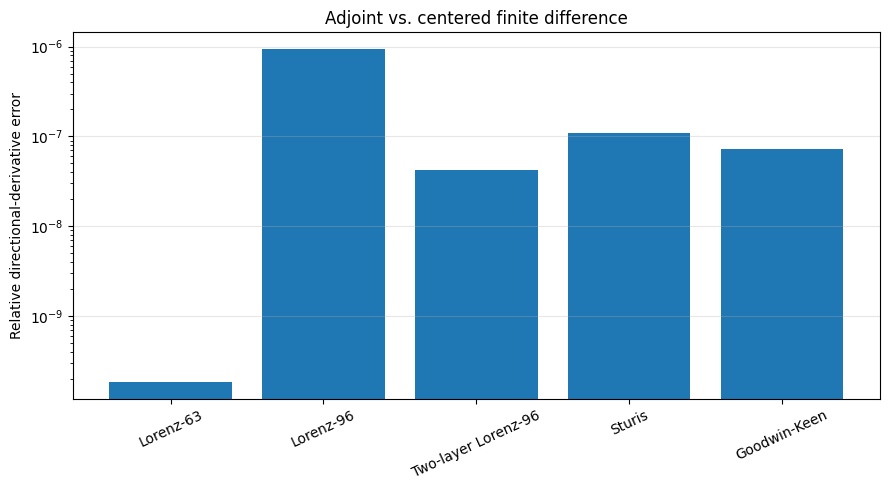

In [63]:
names = [r["name"] for r in results]
errors = [r["relative_error"] for r in results]

plt.figure(figsize=(9, 5))
plt.bar(names, errors)
plt.yscale("log")
plt.ylabel("Relative directional-derivative error")
plt.title("Adjoint vs. centered finite difference")
plt.xticks(rotation=25)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [64]:
for result in results:
    print(result["name"])
    print("grad_x0 J =")
    print(result["gradient"])
    print()

Lorenz-63
grad_x0 J =
[-0.017646 -0.013316 -0.018695]

Lorenz-96
grad_x0 J =
[ -1.509212   4.291356   3.840213  -0.554708  -3.582854  -2.745804
   0.238901   1.289364   0.929435   3.39449    4.564426  -4.067792
 -13.462916  -3.697032  17.429924  15.803587 -12.152844 -24.015158
   1.422749  24.495662   8.159874 -19.853172 -13.770854  14.269961
  16.956833  -8.936325 -19.583563   2.317846  20.535733   5.875551
 -17.177865 -12.365267   9.897312  13.528862  -3.081956 -10.18333
   0.304474   6.900067   0.082652  -5.710056]

Two-layer Lorenz-96
grad_x0 J =
[ 0.076305  0.005151 -0.029836 -0.017474 -0.052422 -0.061085  0.068569
  0.156671  0.004008 -0.176148 -0.093012  0.120096  0.132479 -0.043376
 -0.117789 -0.012152  0.066629  0.023217 -0.033647 -0.038497  0.007276
  0.06212   0.028629 -0.089034 -0.088231  0.080244  0.145564 -0.016097
 -0.144646 -0.050684  0.087764  0.070208 -0.039162 -0.071811 -0.004323
  0.046681  0.006407 -0.054648 -0.026198  0.063272 -0.001625  0.001614
 -0.001888  0.000

## Problem 5

In [65]:
rng = np.random.default_rng(2026)

# Saved target initial state
x0_target = np.array([
    1.0,
    1.0,
    1.0
])

# Keep the horizon moderate for gradient-based inversion
T_opt = 1.0

# Generate terminal target y
target_sol = solve_forward(
    lorenz63,
    x0_target,
    T_opt
)

y_target = target_sol.y[:, -1]

# Random starting initial condition
x0_guess_initial = (
    x0_target
    + rng.normal(
        loc=0.0,
        scale=0.5,
        size=3
    )
)

print("Saved target initial state:")
print(x0_target)

print("\nTarget terminal state:")
print(y_target)

print("\nRandom initial guess:")
print(x0_guess_initial)

Saved target initial state:
[1. 1. 1.]

Target terminal state:
[-9.37857  -8.357034 29.362325]

Random initial guess:
[0.603439 1.120286 0.051837]


In [66]:
def optimize_initial_condition(
    f,
    jac,
    x0_guess,
    y,
    T,
    n_steps=25,
    initial_step_size=0.05
):
    x0 = x0_guess.copy()

    J_history = []
    mismatch_history = []
    x0_history = [x0.copy()]

    for k in range(n_steps):
        J, grad, _, _ = adjoint_gradient(
            f, jac, x0, y, T
        )

        current_sol = solve_forward(
            f, x0, T
        )

        current_mismatch = np.linalg.norm(
            current_sol.y[:, -1] - y
        )

        J_history.append(J)
        mismatch_history.append(current_mismatch)

        # Backtracking line search
        step = initial_step_size

        while step > 1e-10:
            candidate = x0 - step * grad

            candidate_J = cost_from_initial_condition(
                f,
                candidate,
                y,
                T
            )

            if candidate_J < J:
                x0 = candidate
                break

            step *= 0.5

        x0_history.append(x0.copy())

        print(
            f"Iteration {k:2d}: "
            f"J = {J:.6e}, "
            f"mismatch = {current_mismatch:.6e}, "
            f"step = {step:.3e}"
        )

    # Evaluate final point
    final_sol = solve_forward(
        f, x0, T
    )

    final_mismatch = np.linalg.norm(
        final_sol.y[:, -1] - y
    )

    final_J = terminal_cost(
        final_sol.y[:, -1],
        y
    )

    J_history.append(final_J)
    mismatch_history.append(final_mismatch)

    return (
        x0,
        np.array(J_history),
        np.array(mismatch_history),
        np.array(x0_history)
    )


x0_optimized, J_history, mismatch_history, x0_history = (
    optimize_initial_condition(
        lorenz63,
        jac_lorenz63,
        x0_guess_initial,
        y_target,
        T_opt,
        n_steps=25,
        initial_step_size=0.05
    )
)

Iteration  0: J = 1.946973e-01, mismatch = 6.240149e-01, step = 5.000e-02
Iteration  1: J = 1.847359e-01, mismatch = 6.078419e-01, step = 5.000e-02
Iteration  2: J = 1.758430e-01, mismatch = 5.930313e-01, step = 5.000e-02
Iteration  3: J = 1.677916e-01, mismatch = 5.792955e-01, step = 5.000e-02
Iteration  4: J = 1.604178e-01, mismatch = 5.664235e-01, step = 5.000e-02
Iteration  5: J = 1.536008e-01, mismatch = 5.542578e-01, step = 5.000e-02
Iteration  6: J = 1.472504e-01, mismatch = 5.426793e-01, step = 5.000e-02
Iteration  7: J = 1.412976e-01, mismatch = 5.315968e-01, step = 5.000e-02
Iteration  8: J = 1.356891e-01, mismatch = 5.209397e-01, step = 5.000e-02
Iteration  9: J = 1.303832e-01, mismatch = 5.106529e-01, step = 5.000e-02
Iteration 10: J = 1.253466e-01, mismatch = 5.006928e-01, step = 5.000e-02
Iteration 11: J = 1.205525e-01, mismatch = 4.910244e-01, step = 5.000e-02
Iteration 12: J = 1.159789e-01, mismatch = 4.816201e-01, step = 5.000e-02
Iteration 13: J = 1.116078e-01, mismat

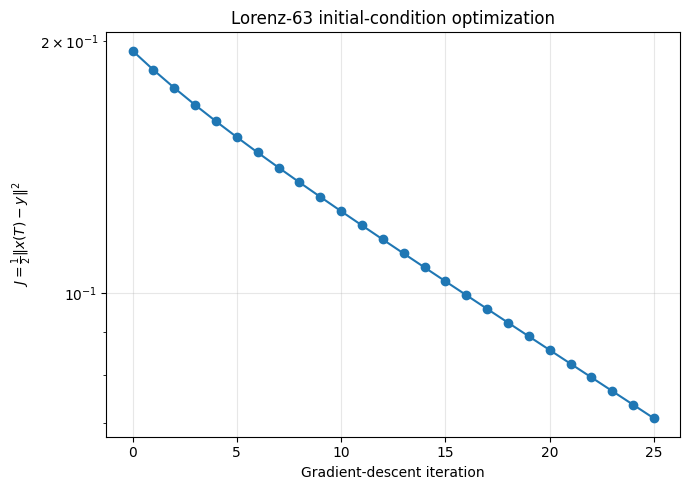

In [67]:
plt.figure(figsize=(7, 5))

plt.semilogy(
    np.arange(len(J_history)),
    J_history,
    marker="o"
)

plt.xlabel("Gradient-descent iteration")
plt.ylabel(r"$J = \frac{1}{2}\|x(T)-y\|^2$")
plt.title("Lorenz-63 initial-condition optimization")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [68]:
initial_sol = solve_forward(
    lorenz63,
    x0_guess_initial,
    T_opt
)

final_sol = solve_forward(
    lorenz63,
    x0_optimized,
    T_opt
)

initial_terminal_state = initial_sol.y[:, -1]
final_terminal_state = final_sol.y[:, -1]

initial_mismatch = np.linalg.norm(
    initial_terminal_state - y_target
)

final_mismatch = np.linalg.norm(
    final_terminal_state - y_target
)

print("Target initial condition:")
print(x0_target)

print("\nInitial guessed initial condition:")
print(x0_guess_initial)

print("\nOptimized initial condition:")
print(x0_optimized)

print("\nTarget terminal state:")
print(y_target)

print("\nInitial terminal state:")
print(initial_terminal_state)

print("\nFinal terminal state:")
print(final_terminal_state)

print("\nInitial terminal mismatch:")
print(initial_mismatch)

print("\nFinal terminal mismatch:")
print(final_mismatch)

print("\nReduction factor:")
print(initial_mismatch / final_mismatch)

Target initial condition:
[1. 1. 1.]

Initial guessed initial condition:
[0.603439 1.120286 0.051837]

Optimized initial condition:
[0.734106 1.207086 0.401037]

Target terminal state:
[-9.37857  -8.357034 29.362325]

Initial terminal state:
[-9.254094 -8.591091 28.79742 ]

Final terminal state:
[-9.263359 -8.426711 29.010399]

Initial terminal mismatch:
0.6240148629524563

Final terminal mismatch:
0.3768027476318772

Reduction factor:
1.6560783244661912


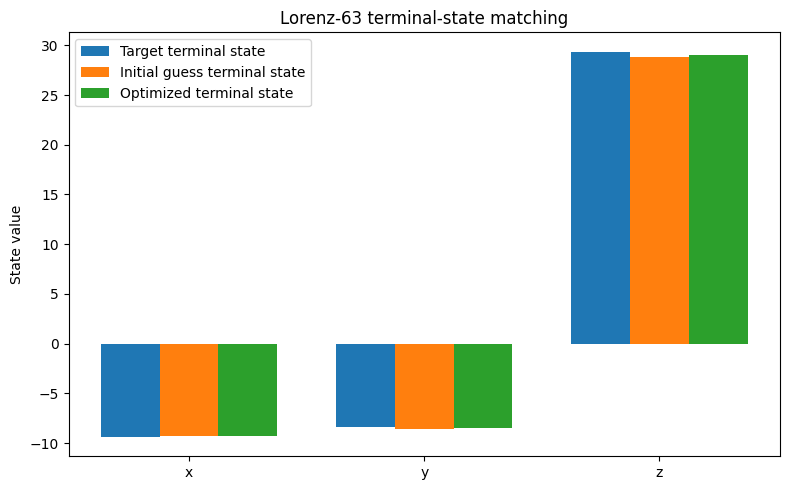

In [69]:
labels = ["x", "y", "z"]
indices = np.arange(3)

width = 0.25

plt.figure(figsize=(8, 5))

plt.bar(
    indices - width,
    y_target,
    width,
    label="Target terminal state"
)

plt.bar(
    indices,
    initial_terminal_state,
    width,
    label="Initial guess terminal state"
)

plt.bar(
    indices + width,
    final_terminal_state,
    width,
    label="Optimized terminal state"
)

plt.xticks(indices, labels)
plt.ylabel("State value")
plt.title("Lorenz-63 terminal-state matching")
plt.legend()
plt.tight_layout()
plt.show()

## Problem 4 Interpretation

The adjoint method was used to compute the gradient of the terminal cost with respect to the initial condition for each deterministic model. The adjoint directional derivative was compared with a centered finite-difference approximation. Close agreement between these two values indicates that the backward adjoint implementation is computing the gradient correctly.

## Problem 5 Interpretation

For the Lorenz-63 model, the adjoint gradient was used in gradient descent to adjust the initial condition so that the terminal state moved closer to a prescribed target state. The decrease in the cost function \(J\) over the iterations, together with the reduction in terminal mismatch, shows that the adjoint gradient provides useful sensitivity information for estimating the initial condition.